# Bus Passenger Demand Forecasting and Timetable Frequency Optimisation

**MSc Data Science — CSCT Masters Project (UFCF9Y-60-M)**
**Student number: 18044142**

This notebook implements the full project pipeline in five stages:

1. **Data engineering** — load the raw MTA hourly ridership export and aggregate it to route–hour grain.
2. **Exploratory analysis** — validate the data and select three contrasting routes for the optimisation demonstration.
3. **Feature engineering and forecasting** — build leakage-safe predictors, benchmark against transparent baselines, and train a gradient-boosted model.
4. **Frequency setting** — convert demand forecasts into recommended buses per hour and headways.
5. **Comparison** — extract the operator's actual scheduled frequencies from GTFS and quantify the gap.

Run the cells in order from the top. The full pipeline takes roughly ten minutes, dominated by the initial CSV parse and the two model fits.

---
## Part 1 — Configuration and data loading

### 1.1 Imports and configuration

All configuration lives in this single cell: file paths, the random seed, the train/validation split dates, and the capacity and policy parameters used by the frequency rule. Keeping them together means every assumption behind the results can be found in one place, and changing a path or a parameter requires editing only one line.

`Path` objects are used rather than plain strings so that paths work across operating systems and handle the spaces in the folder names. Every location is derived from `RAW_CSV`, so moving the project requires changing a single line.

In [1]:
# 1. Imports and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import joblib
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

# --- Configuration (single source of truth) ---
RANDOM_SEED = 42
TRAIN_END = "2024-03-31"
VAL_END   = "2024-08-31"

CAPACITY = 60          # planning passengers per bus
MIN_BUSES_PER_HR = 1   # policy floor
MAX_BUSES_PER_HR = 30  # policy ceiling

RAW_CSV   = Path("MTA_Bus_Hourly_Ridership_2023-24.csv")
PROCESSED = RAW_CSV.parent / "data" / "processed"
OUT_PATH  = PROCESSED / "mta_route_hourly_2023_2024.parquet"
FEATURES_PATH = PROCESSED / "mta_features_2023_2024.parquet"
MODELS    = PROCESSED.parent / "models"
FIGURES   = PROCESSED.parent / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

print("CSV exists:", RAW_CSV.exists())
print("Output will be:", OUT_PATH.resolve())

CSV exists: True
Output will be: /Users/apple/Desktop/MSc Data Science/CSCT Masters Project /data/processed/mta_route_hourly_2023_2024.parquet


### 1.2 Load the raw ridership data

The raw export contains roughly 36 million rows. Two loading decisions matter:

- **`parse_dates`** converts the timestamp column from text into real datetime objects. This is what later makes `.dt.hour` and `.dt.dayofweek` possible, so every calendar feature in the project depends on it.
- **`dtype`** declares each column's type up front rather than letting pandas infer it. Declaring `bus_route` as a category stores the route names once and references them by integer code, and 32-bit integers halve the memory of the count columns.

This is the slowest cell in the notebook.

In [2]:
# 2. Load the data
df = pd.read_csv(
    RAW_CSV,
    thousands= ",",
    dtype={
        "bus_route": "category",
        "ridership": "int32",
        "transfers": "int32",
    },
)

df["transit_timestamp"] = pd.to_datetime(
    df["transit_timestamp"], format="%m/%d/%Y %I:%M:%S %p"
)

print(f"Rows: {len(df):,}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
df.head()

Rows: 36,350,855
Memory: 0.65 GB


,bus_route,ridership,transit_timestamp,transfers
0,B65,1,2023-03-08 23:00:00,0
1,Q20B,16,2023-04-28 16:00:00,4
2,BX26,12,2023-01-18 20:00:00,0
3,M3,93,2023-03-30 15:00:00,27
4,B6,44,2023-01-04 23:00:00,21


### 1.3 Optional: resume from saved data

Cells 1.2 onward rebuild everything from the raw CSV. Once that has been run at least once, the processed files exist on disk and this cell restores the full working state in a few seconds, which is useful when returning to the project after restarting the kernel.

On a full top-to-bottom run this cell is redundant but harmless: the aggregation in Part 1.5 recreates `hourly` from the raw data immediately afterwards.

In [3]:
# Optional: restore saved state if the pipeline has been run before.
# Skipped automatically on a first run, when the saved files do not yet exist.
if FEATURES_PATH.exists():
    hourly = pd.read_parquet(FEATURES_PATH)
    print(f"Loaded {len(hourly):,} rows, {hourly.shape[1]} columns from saved features")
    model_file = MODELS / "lgb_v2_refined.joblib"
    if model_file.exists():
        lgb_v2 = joblib.load(model_file)
        print("Loaded saved v2 model")
else:
    print("No saved features found; the pipeline below will build them from the raw data.")

Loaded 7,456,200 rows, 16 columns from saved features
Loaded saved v2 model


### 1.4 Profile the data before using it

This cell produces no output that is kept; it exists to catch problems before anything is built on top of them. It confirms the date range covers the intended two years, checks the route count is plausible, verifies there are no missing values, and reports the proportion of zero-ridership rows.

The row counts per route measure **data coverage**, not popularity. The low end of that distribution is the informative part: routes with unusually few rows started or ceased service partway through the period, which would leave gaps in the time series and break the lag features built later.

In [4]:
# 3. Basic profile/ Data exploration
print("Date range:", df["transit_timestamp"].min(), "→", df["transit_timestamp"].max())
print("Unique routes:", df["bus_route"].nunique())
print("\nMissing values:\n", df.isna().sum())
print("\nRidership summary:\n", df["ridership"].describe())
print("\nZero-ridership rows:", f"{(df['ridership'] == 0).mean():.1%}")

# Data coverage per route — NOT popularity. Counts rows, and every route
# gets ~8760 hours x ~28 fare classes regardless of how busy it is.
# The LOW end is what matters: these routes likely started or stopped
# service mid-period, which will leave gaps in the time series.
coverage = df["bus_route"].value_counts()
print("\nRow counts — lowest coverage routes:")
print(coverage.tail(15))
print(f"\nMedian rows per route: {coverage.median():,.0f}")

Date range: 2023-01-01 00:00:00 → 2024-12-31 23:00:00
Unique routes: 425

Missing values:
 bus_route            0
ridership            0
transit_timestamp    0
transfers            0
dtype: int64

Ridership summary:
 count    3.635086e+07
mean     2.130138e+01
std      3.920635e+01
min      0.000000e+00
25%      1.000000e+00
50%      7.000000e+00
75%      2.500000e+01
max      1.896000e+03
Name: ridership, dtype: float64

Zero-ridership rows: 20.5%

Row counts — lowest coverage routes:
bus_route
X17J    17544
X19     17544
X2      17544
X21     17544
X22     17544
X22A    17544
X3      17544
X30     17544
X31     17544
X4      17544
X42     17544
X5      17544
X7      17544
X8      17544
X9      17544
Name: count, dtype: int64

Median rows per route: 103,209


### 1.5 Aggregate to route–hour grain

This is the transformation that converts the raw data into the grain the research question is about. Three details matter:

- **`observed=True`** prevents the categorical route column from generating rows for route–hour combinations that never occurred.
- **Sorting within route** is load-bearing rather than cosmetic: the lag features built later read the previous row within each route, so unsorted rows would produce silently incorrect features.
- **`reset_index`** returns the grouping keys to ordinary columns so they can be used normally downstream.

In [5]:
# 4. Aggregate to hourly ridership per route
hourly = (
    df.groupby(["transit_timestamp", "bus_route"], observed=True)[["ridership", "transfers"]]
      .sum()
      .reset_index()
      .sort_values(["bus_route", "transit_timestamp"])
      .reset_index(drop=True)
)

print(f"Rows after aggregation: {len(hourly):,}")
print(f"Reduction: {len(hourly) / len(df):.1%} of original")
hourly.head()

Rows after aggregation: 7,456,200
Reduction: 20.5% of original


,transit_timestamp,bus_route,ridership,transfers
0,2023-01-01 00:00:00,B1,11,2
1,2023-01-01 01:00:00,B1,14,2
2,2023-01-01 02:00:00,B1,20,2
3,2023-01-01 03:00:00,B1,11,1
4,2023-01-01 04:00:00,B1,5,1


### 1.6 Derive time features and persist

Hour, day of week, weekend flag and month are extracted from the parsed timestamp. A machine learning model cannot interpret a datetime object directly, so these components must become their own numeric columns.

The result is written to Parquet, a binary columnar format that preserves column types and loads in seconds where re-parsing the CSV takes minutes. Everything above this point runs once; every later session resumes from this file.

In [6]:
# 5. Add time features and save to Parquet
hourly["hour"] = hourly["transit_timestamp"].dt.hour.astype("int8")
hourly["dayofweek"] = hourly["transit_timestamp"].dt.dayofweek.astype("int8")  # 0=Monday
hourly["is_weekend"] = hourly["dayofweek"] >= 5
hourly["month"] = hourly["transit_timestamp"].dt.month.astype("int8")
hourly["date"] = hourly["transit_timestamp"].dt.date


PROCESSED.mkdir(parents=True, exist_ok=True)


hourly.to_parquet(OUT_PATH, index=False)
print(f"Saved to {OUT_PATH}")
print(f"File size: {OUT_PATH.stat().st_size / 1e6:.1f} MB")

Saved to data/processed/mta_route_hourly_2023_2024.parquet
File size: 28.1 MB


---
## Part 2 — Exploratory analysis and route selection

### 2.1 Route popularity and peak intensity

Two distinct measures are computed here. **Total ridership** identifies the busiest routes. The **peak-to-off-peak ratio** identifies routes whose demand is concentrated in commuting hours, as opposed to those with steady all-day demand.

The ratio is calculated only for routes with above-median volume, so that a route carrying a handful of passengers cannot top the ranking on noise alone. Together these measures select three routes with deliberately different demand shapes for the optimisation demonstration.

In [7]:
# 6. Route popularity and demand profile
# --- Popularity: sum ridership, not row counts ---
route_totals = (
    hourly.groupby("bus_route", observed=True)["ridership"]
    .sum()
    .sort_values(ascending=False)
)
print("Top 10 routes by total ridership (2023–24):")
print(route_totals.head(10).apply(lambda x: f"{x:,}"))

# --- Peak intensity: which routes are commuter-shaped vs all-day ---
PEAK_HOURS = [7, 8, 9, 16, 17, 18]

peak_profile = (
    hourly.assign(is_peak=hourly["hour"].isin(PEAK_HOURS))
    .groupby(["bus_route", "is_peak"], observed=True)["ridership"]
    .mean()
    .unstack()
    .rename(columns={False: "offpeak_mean", True: "peak_mean"})
)
peak_profile["peak_ratio"] = peak_profile["peak_mean"] / peak_profile["offpeak_mean"]
peak_profile["total_ridership"] = route_totals

# Restrict to routes with meaningful volume so tiny routes don't dominate
significant = peak_profile[peak_profile["total_ridership"] > route_totals.median()]

print("\nMost commuter-peaked routes:")
print(significant.sort_values("peak_ratio", ascending=False).head(8).round(2))
print("\nFlattest all-day routes:")
print(significant.sort_values("peak_ratio").head(8).round(2))

Top 10 routes by total ridership (2023–24):
bus_route
Q58     13,337,978
M15+    13,325,870
B6      10,835,214
Q27     10,125,185
Q65      9,365,291
Q25      9,062,051
Q44+     8,607,802
Q10      8,442,841
B41      8,353,623
M15      8,249,222
Name: ridership, dtype: str

Most commuter-peaked routes:
is_peak    offpeak_mean  peak_mean  peak_ratio  total_ridership
bus_route                                                      
B100              68.84     245.99        3.57          1984707
B31               38.76     138.41        3.57          1117020
B69               55.71     197.68        3.55          1600080
B82+             147.40     519.69        3.53          4218857
Q67               37.58     128.52        3.42          1058132
Q11               56.68     183.62        3.24          1551161
S93               47.34     152.59        3.22          1292226
BX23              49.55     158.81        3.20          1348544

Flattest all-day routes:
is_peak    offpeak_mean  peak_me

### 2.2 Weekday and weekend demand profiles

This plot is the single most important validation check in the notebook. A correct result shows twin weekday commuter peaks in the morning and late afternoon, with a flatter and later weekend profile.

It confirms three things at once: that the data is clean, that the expected demand structure is present for a model to learn, and that timestamps are recorded in local time. A timezone offset would shift the peaks by several hours and would silently corrupt every time-based feature in the project.

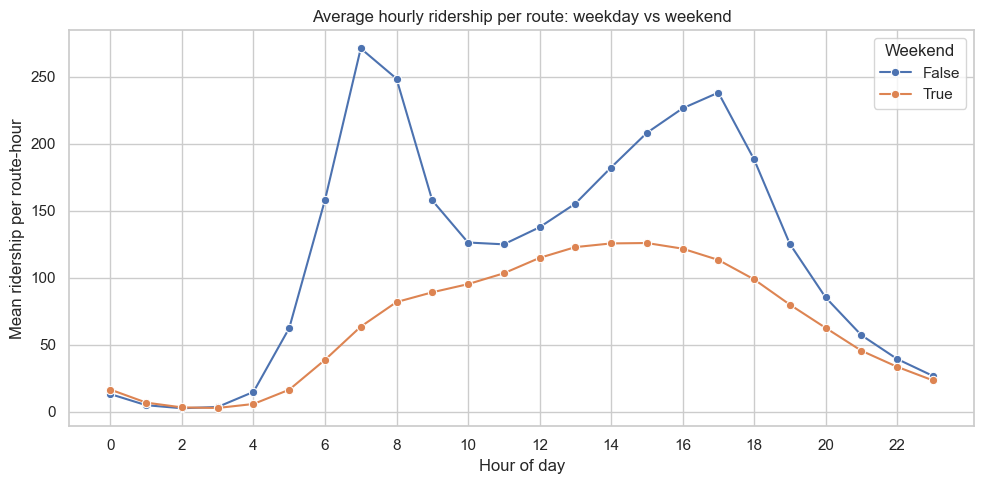

In [8]:
#7. Demand curve plots

profile = (
    hourly.groupby(["hour", "is_weekend"], observed=True)["ridership"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=profile, x="hour", y="ridership", hue="is_weekend", marker="o", ax=ax)
ax.set_title("Average hourly ridership per route: weekday vs weekend")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean ridership per route-hour")
ax.set_xticks(range(0, 24, 2))
ax.legend(title="Weekend")
plt.tight_layout()
plt.show()
fig.savefig(FIGURES / "weekday_vs_weekend_demand.png", dpi=300, bbox_inches="tight")

### 2.3 Contrasting route profiles

The three selected routes are plotted together on a common axis. Their visibly different shapes are the empirical justification for the optimisation component: a single uniform frequency policy cannot serve a sharply peaked commuter route and a flat all-day route equally well.

Converting the route column to strings before plotting removes the unused categories that would otherwise appear in the legend, since categorical columns retain every possible value even after filtering.

Routes selected: ['Q58', 'B100', 'SIM1C']


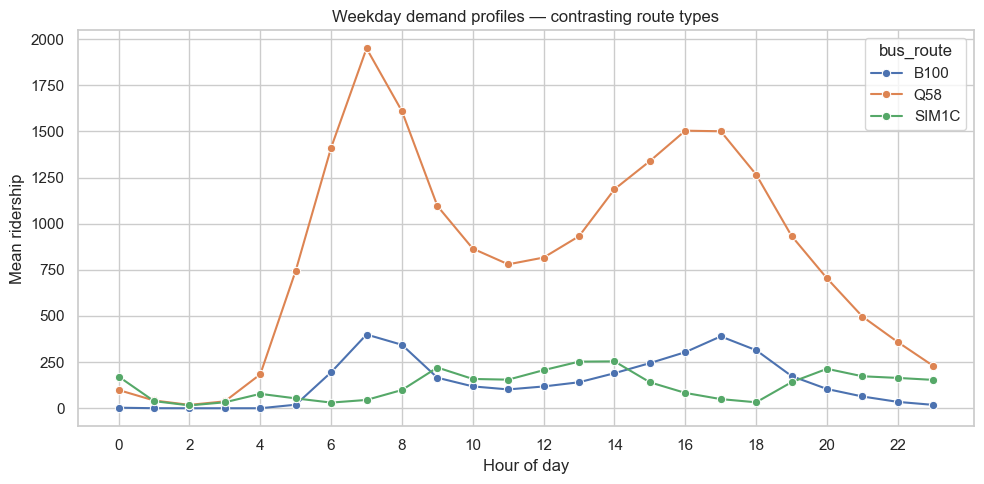

In [9]:
# 8. Contrasting route profiles 
# Pick one high-volume, one commuter-peaked, one flat route to compare
examples = [
    route_totals.index[0],                                              # busiest
    significant.sort_values("peak_ratio", ascending=False).index[0],    # most peaked
    significant.sort_values("peak_ratio").index[0],                     # flattest
]
print("Routes selected:", examples)

subset = (
    hourly[hourly["bus_route"].isin(examples) & ~hourly["is_weekend"]]
    .groupby(["bus_route", "hour"], observed=True)["ridership"]
    .mean()
    .reset_index()
)
subset["bus_route"] = subset["bus_route"].astype(str)   # drop unused categories

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=subset, x="hour", y="ridership", hue="bus_route", marker="o", ax=ax)
ax.set_title("Weekday demand profiles — contrasting route types")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean ridership")
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()
fig.savefig(FIGURES / "contrasting_route_profiles.png", dpi=300, bbox_inches="tight")


---
## Part 3 — Feature engineering and forecasting

### 3.1 Lag and rolling-window features

Recent history is the strongest predictor of transit demand, so this cell builds it explicitly.

- **Lags** at 1, 24 and 168 hours give the model the previous hour, the same hour yesterday, and the same hour last week.
- **Rolling means** smooth recent demand into a level estimate.

Two safeguards prevent data leakage. Every operation is computed *within* each route, so one route's history never bleeds into another's. And every rolling window is shifted by one step first, so a feature never contains the value it is being used to predict.

The rolling features use `transform` rather than a chained `shift().rolling()`, because chaining a second operation onto a grouped result silently discards the grouping. The null counts printed below verify the fix: each divides exactly by the number of routes, proving every route computed its window independently.

In [10]:
# 9. Lag and rolling-window features
hourly = hourly.sort_values(["bus_route", "transit_timestamp"]).reset_index(drop=True)

g = hourly.groupby("bus_route", observed=True)["ridership"]

# Recent history
hourly["lag_1h"]   = g.shift(1)      # previous hour
hourly["lag_24h"]  = g.shift(24)     # same hour yesterday
hourly["lag_168h"] = g.shift(168)    # same hour last week (24 * 7)

# Smoothed recent level — shift(1) first so the current value is excluded
hourly["roll_24h_mean"] = (
    hourly.groupby("bus_route", observed=True)["ridership"]
    .transform(lambda s: s.shift(1).rolling(24, min_periods=12).mean())
)
hourly["roll_168h_mean"] = (
    hourly.groupby("bus_route", observed=True)["ridership"]
    .transform(lambda s: s.shift(1).rolling(168, min_periods=84).mean())
)

print(hourly[["transit_timestamp", "bus_route", "ridership",
              "lag_1h", "lag_24h", "lag_168h", "roll_24h_mean"]].head(10))
print("\nMissing values per lag column:")
print(hourly[["lag_1h", "lag_24h", "lag_168h", "roll_24h_mean", "roll_168h_mean"]].isna().sum())

    transit_timestamp bus_route  ridership  lag_1h  lag_24h  lag_168h  \
0 2023-01-01 00:00:00        B1         11     NaN      NaN       NaN   
1 2023-01-01 01:00:00        B1         14    11.0      NaN       NaN   
2 2023-01-01 02:00:00        B1         20    14.0      NaN       NaN   
3 2023-01-01 03:00:00        B1         11    20.0      NaN       NaN   
4 2023-01-01 04:00:00        B1          5    11.0      NaN       NaN   
5 2023-01-01 05:00:00        B1         26     5.0      NaN       NaN   
6 2023-01-01 06:00:00        B1         42    26.0      NaN       NaN   
7 2023-01-01 07:00:00        B1        164    42.0      NaN       NaN   
8 2023-01-01 08:00:00        B1        214   164.0      NaN       NaN   
9 2023-01-01 09:00:00        B1        258   214.0      NaN       NaN   

   roll_24h_mean  
0            NaN  
1            NaN  
2            NaN  
3            NaN  
4            NaN  
5            NaN  
6            NaN  
7            NaN  
8            NaN  
9     

### 3.2 Save the feature-enriched dataset

Written to a new filename rather than overwriting, so the clean aggregated data remains available as a base if the feature set is later revised.

In [11]:
# 10. Save feature-enriched dataset
FEATURES_PATH = PROCESSED / "mta_features_2023_2024.parquet"
hourly.to_parquet(FEATURES_PATH, index=False)

print(f"Saved to {FEATURES_PATH}")
print(f"File size: {FEATURES_PATH.stat().st_size / 1e6:.1f} MB")
print(f"Columns: {list(hourly.columns)}")

Saved to data/processed/mta_features_2023_2024.parquet
File size: 70.4 MB
Columns: ['transit_timestamp', 'bus_route', 'ridership', 'transfers', 'hour', 'dayofweek', 'is_weekend', 'month', 'date', 'lag_1h', 'lag_24h', 'lag_168h', 'roll_24h_mean', 'roll_168h_mean']


### 3.3 Chronological train, validation and test split

Because this is a time series, the splits are chronological and are fixed **before** any model is trained. A random split would allow the model to learn from later periods when predicting earlier ones, producing accuracy figures that look excellent and mean nothing.

Three partitions are used for a reason: the training set fits the model, the validation set is used to compare and tune models, and the test set is touched only once at the end. Tuning against the test set would make the reported accuracy optimistic.

Rows with missing lag values (the warm-up period at the start of each route's series) are dropped first, costing roughly one per cent of the data.

In [12]:
# 11. Train / validation / test split
TRAIN_END = "2024-03-31"
VAL_END   = "2024-08-31"

model_df = hourly.dropna(subset=["lag_1h", "lag_24h", "lag_168h",
                                 "roll_24h_mean", "roll_168h_mean"]).copy()
print(f"Rows after dropping lag warm-up: {len(model_df):,} "
      f"({len(model_df)/len(hourly):.1%} retained)")

ts = model_df["transit_timestamp"]
train = model_df[ts <= TRAIN_END]
val   = model_df[(ts > TRAIN_END) & (ts <= VAL_END)]
test  = model_df[ts > VAL_END]

for name, part in [("Train", train), ("Val", val), ("Test", test)]:
    print(f"{name:6} {len(part):>10,} rows   "
          f"{part['transit_timestamp'].min()} → {part['transit_timestamp'].max()}")

Rows after dropping lag warm-up: 7,384,800 (99.0% retained)
Train   4,570,025 rows   2023-01-08 00:00:00 → 2024-03-31 00:00:00
Val     1,560,600 rows   2024-03-31 01:00:00 → 2024-08-31 00:00:00
Test    1,254,175 rows   2024-08-31 01:00:00 → 2024-12-31 23:00:00


### 3.4 Baseline models

No accuracy claim is meaningful without a baseline to beat. Three are used:

- **Same hour yesterday** and **same hour last week** test whether demand is simply persistent.
- **Historical average** by route, hour and weekend flag encodes each route's typical demand curve.

The historical average is computed from the **training data only**. Calculating it across the whole dataset would leak validation information into a feature used to predict validation.

MAE is the primary metric because it is interpretable as passengers per route-hour. RMSE is reported alongside because squaring the errors penalises large misses more heavily, and large misses are what matter for capacity planning.

In [13]:
# 12. Baseline models
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{label:28} MAE {mae:7.2f}   RMSE {rmse:7.2f}")
    return {"model": label, "MAE": mae, "RMSE": rmse}

results = []

# Baseline 1: naive — assume this hour equals the same hour yesterday
results.append(evaluate(val["ridership"], val["lag_24h"], "Naive (yesterday, same hour)"))

# Baseline 2: naive — same hour last week
results.append(evaluate(val["ridership"], val["lag_168h"], "Naive (last week, same hour)"))

# Baseline 3: historical average by route / hour / weekend, learned from TRAIN only
hist_avg = (
    train.groupby(["bus_route", "hour", "is_weekend"], observed=True)["ridership"]
    .mean()
    .rename("hist_avg")
)
val_ha = val.merge(hist_avg, on=["bus_route", "hour", "is_weekend"], how="left")
val_ha["hist_avg"] = val_ha["hist_avg"].fillna(train["ridership"].mean())
results.append(evaluate(val_ha["ridership"], val_ha["hist_avg"], "Historical average"))

baseline_results = pd.DataFrame(results)
baseline_results

Naive (yesterday, same hour) MAE   26.28   RMSE   67.16
Naive (last week, same hour) MAE   16.54   RMSE   41.06
Historical average           MAE   18.99   RMSE   44.61


,model,MAE,RMSE
0,"Naive (yesterday, same hour)",26.281528,67.161896
1,"Naive (last week, same hour)",16.540495,41.058718
2,Historical average,18.987257,44.611342


In [14]:
baseline_results.to_csv(PROCESSED / "baseline_results.csv", index=False)

### 3.5 Assemble the feature matrix

Defining the feature list explicitly guarantees that every model receives identical inputs, and wrapping the conversion in a function guarantees that training and validation data are treated identically.

The route identifier is kept as a categorical rather than one-hot encoded, because LightGBM handles categorical features natively and one-hot encoding 425 routes would create 425 columns.

In [15]:
# 13. Assemble feature matrix
FEATURES = [
    "hour", "dayofweek", "is_weekend", "month",
    "lag_1h", "lag_24h", "lag_168h",
    "roll_24h_mean", "roll_168h_mean",
    "bus_route",
]
TARGET = "ridership"

def xy(part):
    X = part[FEATURES].copy()
    X["is_weekend"] = X["is_weekend"].astype("int8")
    X["bus_route"] = X["bus_route"].astype("category")
    return X, part[TARGET]

X_train, y_train = xy(train)
X_val,   y_val   = xy(val)

print(f"Train: {X_train.shape}   Val: {X_val.shape}")
print(X_train.dtypes)

Train: (4570025, 10)   Val: (1560600, 10)
hour                  int8
dayofweek             int8
is_weekend            int8
month                 int8
lag_1h             float64
lag_24h            float64
lag_168h           float64
roll_24h_mean      float64
roll_168h_mean     float64
bus_route         category
dtype: object


### 3.6 Gradient-boosted model (LightGBM)

LightGBM was selected for three reasons specific to this data: it trains on 4.5 million rows in under a minute, it handles the 425-level route categorical natively, and it exposes interpretable feature importances.

Early stopping monitors validation error and halts training when it stops improving, which finds an appropriate number of trees automatically rather than requiring one to be guessed.

In [16]:
# 14. LightGBM — tuned
lgb_model = lgb.LGBMRegressor(
    n_estimators=1500,
    learning_rate=0.05,
    num_leaves=63,
    max_cat_threshold=512,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=-1,
)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="l1",
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
)

print(f"Best iteration: {lgb_model.best_iteration_}")
results.append(evaluate(y_val, lgb_model.predict(X_val), "LightGBM (tuned)"))
pd.DataFrame(results)

/Users/apple/Desktop/MSc Data Science/venv/lib/python3.14/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Training until validation scores don't improve for 50 rounds
[100]	valid_0's l1: 12.4015	valid_0's l2: 638.124
[200]	valid_0's l1: 11.6464	valid_0's l2: 571.471
[300]	valid_0's l1: 11.4264	valid_0's l2: 546.244
[400]	valid_0's l1: 11.271	valid_0's l2: 529.904
[500]	valid_0's l1: 11.1692	valid_0's l2: 519.466
[600]	valid_0's l1: 11.09	valid_0's l2: 511.927
[700]	valid_0's l1: 11.0319	valid_0's l2: 506.437
[800]	valid_0's l1: 10.9778	valid_0's l2: 501.675
[900]	valid_0's l1: 10.9318	valid_0's l2: 498.022
[1000]	valid_0's l1: 10.8877	valid_0's l2: 494.851
[1100]	valid_0's l1: 10.8611	valid_0's l2: 492.802
[1200]	valid_0's l1: 10.8339	valid_0's l2: 490.779
[1300]	valid_0's l1: 10.8096	valid_0's l2: 488.742
[1400]	valid_0's l1: 10.7817	valid_0's l2: 486.991
[1500]	valid_0's l1: 10.7596	valid_0's l2: 485.31
Did not meet early stopping. Best iteration is:
[1500]	valid_0's l1: 10.7596	valid_0's l2: 485.31
Best iteration: 1500
LightGBM (tuned)             MAE   10.76   RMSE   22.03


,model,MAE,RMSE
0,"Naive (yesterday, same hour)",26.281528,67.161896
1,"Naive (last week, same hour)",16.540495,41.058718
2,Historical average,18.987257,44.611342
3,LightGBM (tuned),10.759588,22.029745


### 3.7 Feature importance: split count and gain

Two importance measures are computed because they answer different questions and, in this case, disagree instructively.

**Split count** records how often each feature is used to divide the data. **Gain** records how much each feature actually reduced prediction error. A categorical with hundreds of levels necessarily requires many splits, but those splits may each contribute very little.

Both are plotted below. The discrepancy between them is discussed in the report.

bus_route         26562
lag_1h            12464
hour              12288
lag_168h          11712
lag_24h            8720
roll_24h_mean      6758
dayofweek          5769
month              5567
roll_168h_mean     3142
is_weekend           18
dtype: int32


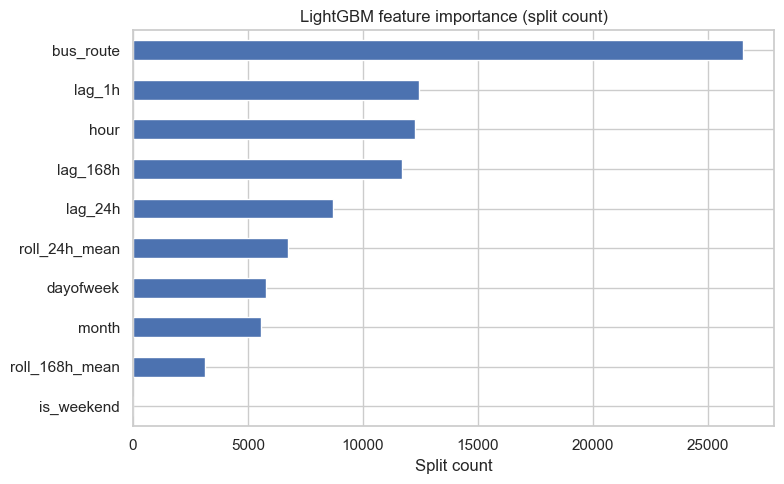

In [17]:
# 15. Feature importance (split count)
imp = (
    pd.Series(lgb_model.feature_importances_, index=lgb_model.feature_name_)
    .sort_values(ascending=False)
)
print(imp)

fig, ax = plt.subplots(figsize=(8, 5))
imp.plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_title("LightGBM feature importance (split count)")
ax.set_xlabel("Split count")
plt.tight_layout()
plt.show()

lag_168h          91.9
lag_1h             4.5
lag_24h            1.3
hour               1.1
bus_route          0.7
dayofweek          0.3
roll_24h_mean      0.1
month              0.0
roll_168h_mean     0.0
is_weekend         0.0
dtype: float64


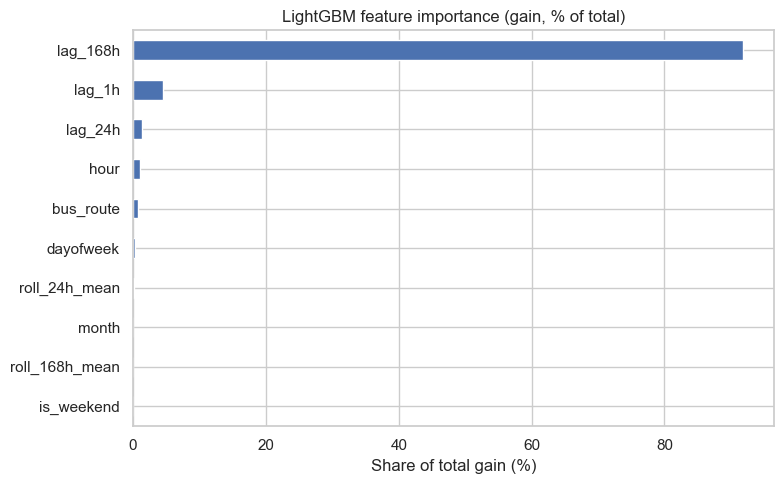

In [18]:
gain = (
    pd.Series(lgb_model.booster_.feature_importance(importance_type="gain"),
              index=lgb_model.feature_name_)
    .sort_values(ascending=False)
)
gain_pct = (gain / gain.sum() * 100).round(1)
print(gain_pct)

fig, ax = plt.subplots(figsize=(8, 5))
gain_pct.plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_title("LightGBM feature importance (gain, % of total)")
ax.set_xlabel("Share of total gain (%)")
plt.tight_layout()
plt.show()

### 3.8 Freeze the current model before refining it

The trained model and results are written to disk before any changes are made, so that the earlier version remains available for comparison. `FEATURES.copy()` takes an independent copy of the feature list; without it, later modifications would alter the snapshot as well.

In [19]:
# 16. Freeze v1 before feature refinement
import joblib

MODELS = PROCESSED.parent / "models"
MODELS.mkdir(parents=True, exist_ok=True)

joblib.dump(lgb_model, MODELS / "lgb_v1_initial_features.joblib")

FEATURES_V1 = FEATURES.copy()          # snapshot the v1 feature list
results_v1 = pd.DataFrame(results)
results_v1.to_csv(PROCESSED / "results_v1_initial_features.csv", index=False)

print("v1 features:", FEATURES_V1)
print(f"v1 best: MAE {results_v1['MAE'].min():.3f}")
results_v1

v1 features: ['hour', 'dayofweek', 'is_weekend', 'month', 'lag_1h', 'lag_24h', 'lag_168h', 'roll_24h_mean', 'roll_168h_mean', 'bus_route']
v1 best: MAE 10.760


,model,MAE,RMSE
0,"Naive (yesterday, same hour)",26.281528,67.161896
1,"Naive (last week, same hour)",16.540495,41.058718
2,Historical average,18.987257,44.611342
3,LightGBM (tuned),10.759588,22.029745


### 3.9 Refined features: same-slot statistics

The initial feature set included a 168-hour rolling mean, which smooths across all hours of the week and therefore loses the phase alignment that makes the weekly lag so effective.

These replacement features group by route, weekday **and** hour, so each series is a sequence of consecutive occurrences of the same weekly slot, for example every Tuesday at 08:00. Averaging the previous four occurrences reduces single-week noise while preserving phase alignment. The standard deviation over the same window gives the model a measure of how volatile that slot is.

In [20]:
# 17. v2 feature — mean of the same weekday+hour over recent weeks
hourly = hourly.sort_values(["bus_route", "transit_timestamp"]).reset_index(drop=True)

slot = hourly.groupby(["bus_route", "dayofweek", "hour"], observed=True)["ridership"]
hourly["slot_mean_4w"] = slot.transform(lambda s: s.shift(1).rolling(4, min_periods=2).mean())
hourly["slot_std_4w"]  = slot.transform(lambda s: s.shift(1).rolling(4, min_periods=2).std())

print(hourly[["transit_timestamp", "bus_route", "dayofweek", "hour",
              "ridership", "lag_168h", "slot_mean_4w", "slot_std_4w"]].head(15))
print("\nNulls:", hourly[["slot_mean_4w", "slot_std_4w"]].isna().sum().to_dict())

     transit_timestamp bus_route  dayofweek  hour  ridership  lag_168h  \
0  2023-01-01 00:00:00        B1          6     0         11       NaN   
1  2023-01-01 01:00:00        B1          6     1         14       NaN   
2  2023-01-01 02:00:00        B1          6     2         20       NaN   
3  2023-01-01 03:00:00        B1          6     3         11       NaN   
4  2023-01-01 04:00:00        B1          6     4          5       NaN   
5  2023-01-01 05:00:00        B1          6     5         26       NaN   
6  2023-01-01 06:00:00        B1          6     6         42       NaN   
7  2023-01-01 07:00:00        B1          6     7        164       NaN   
8  2023-01-01 08:00:00        B1          6     8        214       NaN   
9  2023-01-01 09:00:00        B1          6     9        258       NaN   
10 2023-01-01 10:00:00        B1          6    10        243       NaN   
11 2023-01-01 11:00:00        B1          6    11        288       NaN   
12 2023-01-01 12:00:00        B1      

### 3.10 Retrain with the refined feature set

The v2 feature set adds the two slot features and removes three that contributed negligible gain, producing a smaller feature set. The model is retrained under otherwise identical settings so the comparison isolates the effect of the features.

In [21]:
# 18. v2 model — refined features
FEATURES_V2 = [
    "hour", "dayofweek",
    "lag_1h", "lag_24h", "lag_168h",
    "roll_24h_mean",
    "slot_mean_4w", "slot_std_4w",
    "bus_route",
]
# dropped from v1: is_weekend (zero gain, derivable from dayofweek)
#                  month (negligible gain)
#                  roll_168h_mean (negligible gain, superseded by slot_mean_4w)

model_df2 = hourly.dropna(subset=[f for f in FEATURES_V2 if f != "bus_route"]).copy()
ts2 = model_df2["transit_timestamp"]
train2 = model_df2[ts2 <= TRAIN_END]
val2   = model_df2[(ts2 > TRAIN_END) & (ts2 <= VAL_END)]

def xy2(part):
    X = part[FEATURES_V2].copy()
    X["bus_route"] = X["bus_route"].astype("category")
    return X, part[TARGET]

X_train2, y_train2 = xy2(train2)
X_val2,   y_val2   = xy2(val2)
print(f"Train: {X_train2.shape}   Val: {X_val2.shape}")

lgb_v2 = lgb.LGBMRegressor(
    n_estimators=1500, learning_rate=0.05, num_leaves=63,
    max_cat_threshold=512, random_state=RANDOM_SEED, n_jobs=-1, verbose=-1,
)
lgb_v2.fit(X_train2, y_train2, eval_set=[(X_val2, y_val2)], eval_metric="l1",
           callbacks=[lgb.early_stopping(50), lgb.log_evaluation(250)])

results.append(evaluate(y_val2, lgb_v2.predict(X_val2), "LightGBM v2 (refined)"))
pd.DataFrame(results)

Train: (4498625, 9)   Val: (1560600, 9)


/Users/apple/Desktop/MSc Data Science/venv/lib/python3.14/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Training until validation scores don't improve for 50 rounds
[250]	valid_0's l1: 10.876	valid_0's l2: 516.632
[500]	valid_0's l1: 10.6768	valid_0's l2: 498.381
[750]	valid_0's l1: 10.5836	valid_0's l2: 490.01
[1000]	valid_0's l1: 10.5245	valid_0's l2: 484.873
[1250]	valid_0's l1: 10.4884	valid_0's l2: 481.805
[1500]	valid_0's l1: 10.4607	valid_0's l2: 479.455
Did not meet early stopping. Best iteration is:
[1500]	valid_0's l1: 10.4607	valid_0's l2: 479.455
LightGBM v2 (refined)        MAE   10.46   RMSE   21.90


,model,MAE,RMSE
0,"Naive (yesterday, same hour)",26.281528,67.161896
1,"Naive (last week, same hour)",16.540495,41.058718
2,Historical average,18.987257,44.611342
3,LightGBM (tuned),10.759588,22.029745
4,LightGBM v2 (refined),10.460743,21.896453


### 3.11 Verify the comparison is like-for-like

The v2 features drop slightly more warm-up rows, so before accepting the improvement it is necessary to confirm both models were evaluated on the same validation rows. If the indices are identical, the difference in accuracy reflects the features rather than a change in the evaluation data.

In [22]:
print("v1 val rows:", len(val), " v2 val rows:", len(val2))
print("Identical val index:", val.index.equals(val2.index))

v1 val rows: 1560600  v2 val rows: 1560600
Identical val index: True


### 3.12 Freeze the final model

The refined model and the full results table are persisted, completing the forecasting stage.

In [23]:
joblib.dump(lgb_v2, MODELS / "lgb_v2_refined.joblib")
pd.DataFrame(results).to_csv(PROCESSED / "results_v2_refined.csv", index=False)
print ("v2 frozen.")

v2 frozen.


---
## Part 4 — Frequency setting

### 4.1 The frequency-setting rule

Forecast demand is converted into a service recommendation using a transparent rule based on Ceder (1984): the number of buses required equals demand divided by a planning capacity, bounded by policy limits.

Three design decisions are deliberate:

- **Rounding up.** Under-provision strands passengers while over-provision wastes resources, and that asymmetry justifies rounding up rather than to the nearest whole bus.
- **A policy floor** ensures a minimum service is retained even when demand approaches zero overnight.
- **A policy ceiling** reflects the practical limits of road space and fleet size.

The function is verified on boundary cases before being applied to real forecasts.

In [24]:
# 19. Frequency-setting function (Ceder-style)

CAPACITY = 60          # planning passengers per bus
MIN_BUSES_PER_HR = 1   # policy floor — never fewer than this while in service
MAX_BUSES_PER_HR = 30  # policy ceiling — road/fleet limit (~every 2 min)

def recommend_frequency(demand, capacity=CAPACITY,
                        min_bph=MIN_BUSES_PER_HR, max_bph=MAX_BUSES_PER_HR):
    """
    Convert an hourly demand estimate into a service recommendation.
    Returns buses/hour (rounded up) and headway in minutes.
    """
    raw = demand / capacity                       # buses needed, unrounded
    buses = int(np.ceil(raw))                     # round UP — under-provision is worse
    buses = max(min_bph, min(buses, max_bph))     # clamp to policy bounds
    headway = 60 / buses                          # minutes between buses
    return buses, round(headway, 1)

for d in [0, 30, 60, 150, 300, 1200, 2500]:
    b, h = recommend_frequency(d)
    print(f"demand {d:>5} → {b:>2} buses/hr, headway {h:>4} min")

demand     0 →  1 buses/hr, headway 60.0 min
demand    30 →  1 buses/hr, headway 60.0 min
demand    60 →  1 buses/hr, headway 60.0 min
demand   150 →  3 buses/hr, headway 20.0 min
demand   300 →  5 buses/hr, headway 12.0 min
demand  1200 → 20 buses/hr, headway  3.0 min
demand  2500 → 30 buses/hr, headway  2.0 min


### 4.2 Apply the rule to predicted demand

For each of the three selected routes, the model predicts demand for every weekday route-hour. These are averaged by hour into a typical weekday profile, which is the appropriate basis for a timetable: frequency setting is a planning decision over a period rather than a real-time control action, so averaging removes idiosyncratic single-day variation.

Each hour's average demand is then passed through the frequency rule to produce a recommended number of buses and the corresponding headway.

In [25]:
# 20. Apply frequency-setting to the three routes' predicted demand
FEATURES_V2 = [
    "hour", "dayofweek",
    "lag_1h", "lag_24h", "lag_168h",
    "roll_24h_mean",
    "slot_mean_4w", "slot_std_4w",
    "bus_route",
]
ROUTES = ["Q58", "B100", "SIM1C"]

def route_recommendations(route, part=None):
    """Typical-weekday demand + frequency recommendation for one route."""
    df_r = hourly[(hourly["bus_route"] == route) & (~hourly["is_weekend"])].copy()
    df_r = df_r.dropna(subset=[f for f in FEATURES_V2 if f != "bus_route"])

    X = df_r[FEATURES_V2].copy()
    X["bus_route"] = X["bus_route"].astype("category")
    df_r["pred_demand"] = lgb_v2.predict(X)

    # Average the predicted demand by hour → one typical weekday profile
    prof = df_r.groupby("hour", observed=True)["pred_demand"].mean().reset_index()
    prof["route"] = route
    recs = prof["pred_demand"].apply(recommend_frequency)
    prof["rec_buses"]   = [r[0] for r in recs]
    prof["rec_headway"] = [r[1] for r in recs]
    return prof

route_profiles = pd.concat([route_recommendations(r) for r in ROUTES], ignore_index=True)
print(route_profiles.to_string(index=False))

 hour  pred_demand route  rec_buses  rec_headway
    0   102.917702   Q58          2         30.0
    1    43.108735   Q58          1         60.0
    2    19.002355   Q58          1         60.0
    3    37.487774   Q58          1         60.0
    4   182.989842   Q58          4         15.0
    5   745.209894   Q58         13          4.6
    6  1413.611798   Q58         24          2.5
    7  1940.573136   Q58         30          2.0
    8  1610.552206   Q58         27          2.2
    9  1089.578264   Q58         19          3.2
   10   866.087340   Q58         15          4.0
   11   782.437712   Q58         14          4.3
   12   823.427897   Q58         14          4.3
   13   934.658647   Q58         16          3.8
   14  1183.000617   Q58         20          3.0
   15  1345.451602   Q58         23          2.6
   16  1494.453485   Q58         25          2.4
   17  1505.673141   Q58         26          2.3
   18  1265.584383   Q58         22          2.7
   19   931.274527  

In [26]:
route_profiles.to_csv(PROCESSED / "frequency_recommendations.csv", index=False)
print("Saved recommendations.")

Saved recommendations.


### 4.3 Visualise demand against recommended service

Each route is plotted with predicted demand as bars against the left axis and recommended headway as a line against the right axis. A second axis is necessary because demand and headway occupy very different numerical ranges.

The two series should move inversely: where demand rises, the headway falls as buses become more frequent. That inverse relationship is the frequency-setting rule made visible, and the differences between the three panels show why route-specific strategies are needed.

Figure saved.


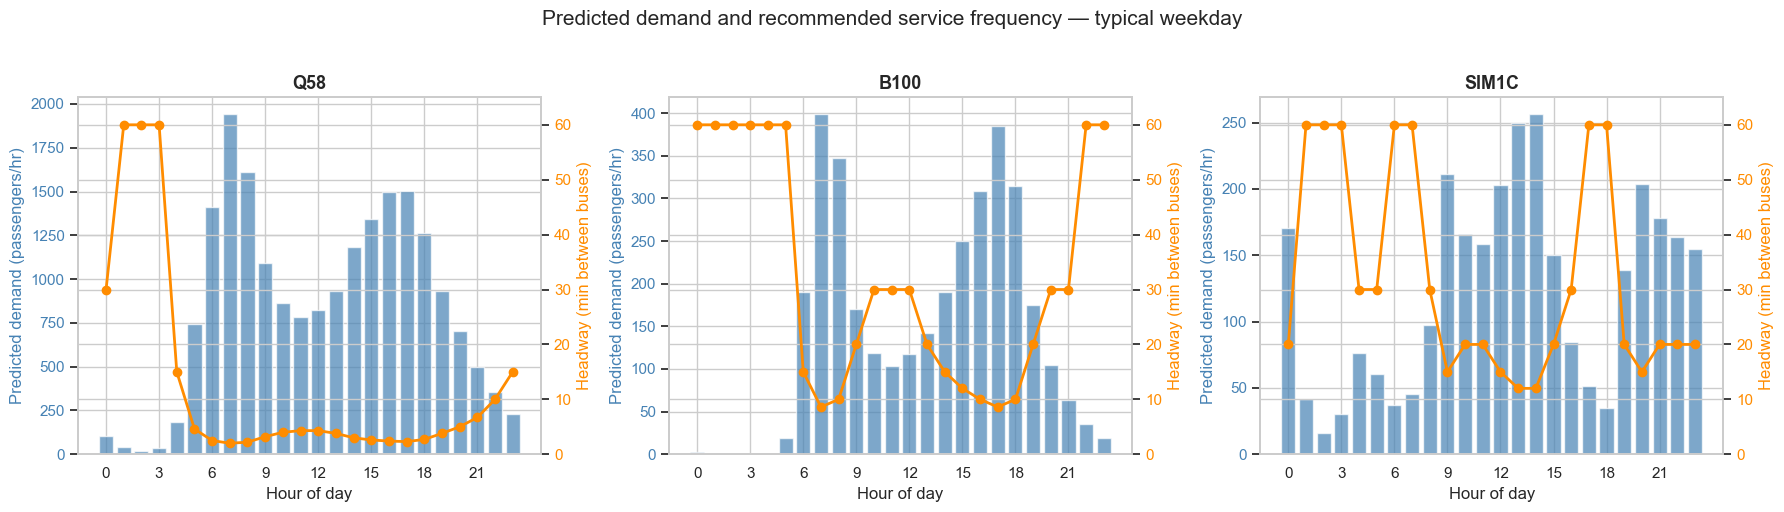

In [27]:
# 21. Visualise demand and recommended frequency per route
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

for ax, route in zip(axes, ROUTES):
    prof = route_profiles[route_profiles["route"] == route]

    # Bars: predicted demand (left axis)
    ax.bar(prof["hour"], prof["pred_demand"], color="steelblue", alpha=0.7, label="Predicted demand")
    ax.set_title(f"{route}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Predicted demand (passengers/hr)", color="steelblue")
    ax.tick_params(axis="y", labelcolor="steelblue")
    ax.set_xticks(range(0, 24, 3))

    # Line: recommended headway (right axis)
    ax2 = ax.twinx()
    ax2.plot(prof["hour"], prof["rec_headway"], color="darkorange", marker="o",
             linewidth=2, label="Recommended headway")
    ax2.set_ylabel("Headway (min between buses)", color="darkorange")
    ax2.tick_params(axis="y", labelcolor="darkorange")
    ax2.set_ylim(0, 65)

fig.suptitle("Predicted demand and recommended service frequency — typical weekday",
             fontsize=15, y=1.02)
plt.tight_layout()
FIGURES = PROCESSED.parent / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURES / "demand_frequency_by_route.png", dpi=300, bbox_inches="tight")
print("Figure saved.")
plt.show()

---
## Part 5 — Comparison against the operated timetable

### 5.1 Locate the routes in the GTFS feeds

The comparison requires the operator's actual scheduled frequencies, which come from GTFS timetable feeds rather than the ridership data.

Two properties of MTA's feeds shaped this step. The per-borough feeds are full-network route **catalogues**, but trip schedules are partitioned by operating division, so B100 is scheduled in the MTA Bus Company feed rather than the Brooklyn feed. SIM1C appears in the NYCT route catalogue but its schedule is published in a separate express feed that was not among those accessed, so the comparison covers Q58 and B100 only. SIM1C's demand analysis and recommendations, which do not depend on GTFS, are retained.

This cell resolves each route's human-readable name to the internal identifier used throughout the rest of the feed.

In [28]:
# 22. GTFS feeds — Q58 and B100 (SIM1C schedule not in accessed feeds)
GTFS = {
    "Q58":  RAW_CSV.parent / "data" / "gtfs_q",
    "B100": RAW_CSV.parent / "data" / "gtfs_busco",
}
COMPARE_ROUTES = ["Q58", "B100"]   # routes with GTFS schedules available

def load_gtfs_route(route_name, folder):
    routes = pd.read_csv(folder / "routes.txt")
    match = routes[routes["route_short_name"].astype(str) == route_name]
    if match.empty:
        print(f"{route_name}: NOT FOUND in {folder.name}")
        return None
    rid = match["route_id"].iloc[0]
    print(f"{route_name}: route_id = {rid}  (feed: {folder.name})")
    return rid

route_ids = {r: load_gtfs_route(r, f) for r, f in GTFS.items()}

Q58: route_id = Q58  (feed: gtfs_q)
B100: route_id = B100  (feed: gtfs_busco)


### 5.2 Count scheduled trips per hour

Three steps convert the feed into an hourly frequency count.

First, weekday service patterns are selected from `calendar.txt`, matching the weekday demand analysis. Second, each trip's first stop time is taken as its departure, since that is what "a bus leaves at 08:15" means; the stop times file is streamed in chunks because it is too large to load comfortably in one piece. Third, the departure hour is extracted, applying modulo arithmetic because GTFS represents after-midnight trips with hours of 24 or greater to keep each service day contiguous.

Reindexing to all 24 hours ensures that hours with no service appear explicitly as zero rather than being silently dropped, which protects the merge that follows.

In [29]:
# 23. Count scheduled trips per hour for each route (typical weekday)

def weekday_service_ids(folder):
    """Service IDs that run Mon–Fri, from calendar.txt."""
    cal = pd.read_csv(folder / "calendar.txt")
    weekday = cal[(cal["monday"] == 1) & (cal["tuesday"] == 1) &
                  (cal["wednesday"] == 1) & (cal["thursday"] == 1) &
                  (cal["friday"] == 1)]
    return set(weekday["service_id"])

def actual_trips_per_hour(route_name, route_id, folder):
    """Count scheduled departures per hour for one route on a typical weekday."""
    # 1. Trips on this route that run on a weekday
    trips = pd.read_csv(folder / "trips.txt")
    svc = weekday_service_ids(folder)
    route_trips = trips[(trips["route_id"] == route_id) &
                        (trips["service_id"].isin(svc))]
    trip_ids = set(route_trips["trip_id"])

    # 2. Each trip's FIRST stop = its departure. stop_times is large, so read in chunks.
    departures = []
    for chunk in pd.read_csv(folder / "stop_times.txt",
                             usecols=["trip_id", "stop_sequence", "departure_time"],
                             chunksize=500_000):
        c = chunk[chunk["trip_id"].isin(trip_ids)]
        first_stops = c[c["stop_sequence"] == c.groupby("trip_id")["stop_sequence"].transform("min")]
        departures.append(first_stops)
    dep = pd.concat(departures, ignore_index=True)

    # 3. Extract the hour. GTFS times can read '25:10:00' (after-midnight trips) → mod 24.
    dep["hour"] = (dep["departure_time"].str.split(":").str[0].astype(int)) % 24

    counts = dep.groupby("hour").size().reindex(range(24), fill_value=0)
    result = pd.DataFrame({"hour": range(24), "actual_buses": counts.values})
    result["route"] = route_name
    print(f"{route_name}: {len(trip_ids)} weekday trips, "
          f"peak {result['actual_buses'].max()} buses/hr")
    return result

actual = pd.concat(
    [actual_trips_per_hour(r, route_ids[r], GTFS[r]) for r in COMPARE_ROUTES],
    ignore_index=True
)

Q58: 329 weekday trips, peak 26 buses/hr
B100: 220 weekday trips, peak 24 buses/hr


### 5.3 Compare recommended against actual frequency

The recommendations and the scheduled counts are joined on route and hour, and the signed gap is computed. A positive gap means the model recommends more service than is currently operated; a negative gap means less.

In the plot, shading marks the divergence between the two lines. The interpretation of these results, including the systematic gap on B100 and its likely causes, is discussed in the report.

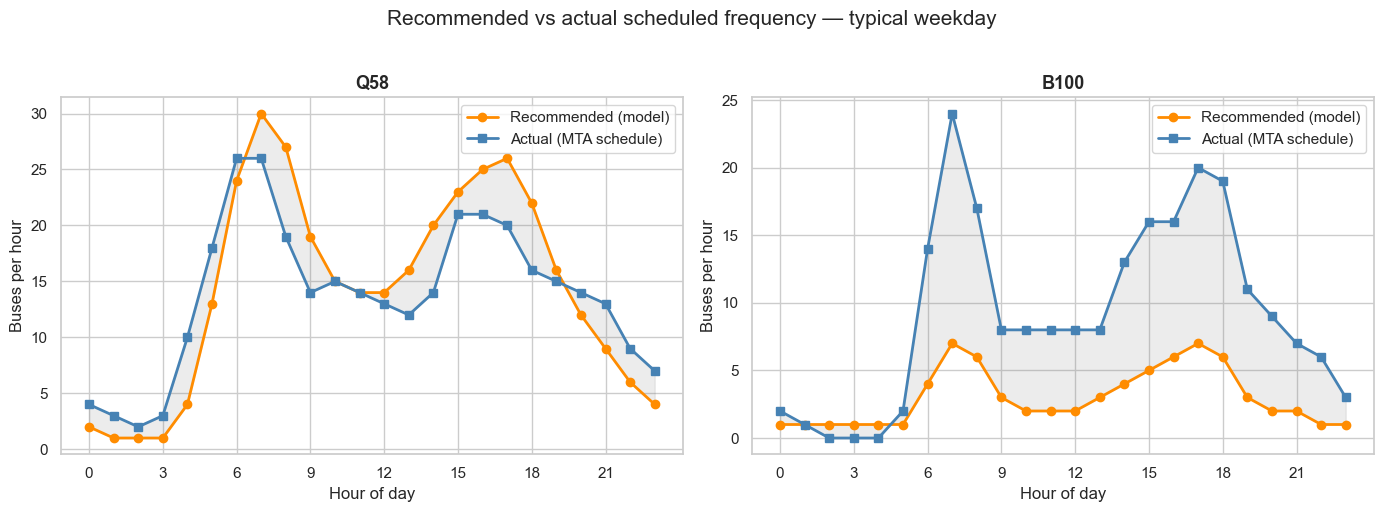

route  hour  pred_demand  rec_buses  actual_buses  gap
  Q58     0   102.917702          2             4   -2
  Q58     1    43.108735          1             3   -2
  Q58     2    19.002355          1             2   -1
  Q58     3    37.487774          1             3   -2
  Q58     4   182.989842          4            10   -6
  Q58     5   745.209894         13            18   -5
  Q58     6  1413.611798         24            26   -2
  Q58     7  1940.573136         30            26    4
  Q58     8  1610.552206         27            19    8
  Q58     9  1089.578264         19            14    5
  Q58    10   866.087340         15            15    0
  Q58    11   782.437712         14            14    0
  Q58    12   823.427897         14            13    1
  Q58    13   934.658647         16            12    4
  Q58    14  1183.000617         20            14    6
  Q58    15  1345.451602         23            21    2
  Q58    16  1494.453485         25            21    4
  Q58    1

In [30]:
# 24. Compare recommended vs actual scheduled frequency

# Bring the two sides together on route + hour
comp = (
    route_profiles[route_profiles["route"].isin(COMPARE_ROUTES)]
    .merge(actual, on=["route", "hour"], how="left")
)
comp["actual_buses"] = comp["actual_buses"].fillna(0).astype(int)
comp["gap"] = comp["rec_buses"] - comp["actual_buses"]   # + = under-served, − = over-served

# Plot: recommended vs actual, one panel per route
fig, axes = plt.subplots(1, len(COMPARE_ROUTES), figsize=(14, 5), sharex=True)

for ax, route in zip(axes, COMPARE_ROUTES):
    d = comp[comp["route"] == route]
    ax.plot(d["hour"], d["rec_buses"], marker="o", linewidth=2,
            color="darkorange", label="Recommended (model)")
    ax.plot(d["hour"], d["actual_buses"], marker="s", linewidth=2,
            color="steelblue", label="Actual (MTA schedule)")
    ax.fill_between(d["hour"], d["rec_buses"], d["actual_buses"],
                    alpha=0.15, color="grey")
    ax.set_title(route, fontsize=13, fontweight="bold")
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Buses per hour")
    ax.set_xticks(range(0, 24, 3))
    ax.legend()

fig.suptitle("Recommended vs actual scheduled frequency — typical weekday",
             fontsize=15, y=1.02)
plt.tight_layout()
fig.savefig(FIGURES / "recommended_vs_actual.png", dpi=300, bbox_inches="tight")
plt.show()

# Summary table
print(comp[["route", "hour", "pred_demand", "rec_buses", "actual_buses", "gap"]]
      .to_string(index=False))

### 5.4 Persist the comparison and summarise the gap

Two summary statistics are computed per route. The **mean absolute gap** measures the typical size of the disagreement. The **mean signed gap** reveals whether the disagreement is balanced or systematically in one direction, which is the more diagnostic of the two.

In [31]:
# 25. Persist comparison outputs + headline gap metrics
comp.to_csv(PROCESSED / "recommended_vs_actual.csv", index=False)

for route in COMPARE_ROUTES:
    d = comp[comp["route"] == route]
    print(f"{route}: mean |gap| = {d['gap'].abs().mean():.1f} buses/hr, "
          f"mean signed gap = {d['gap'].mean():+.1f}")
print("Comparison saved.")

Q58: mean |gap| = 3.3 buses/hr, mean signed gap = +0.6
B100: mean |gap| = 6.4 buses/hr, mean signed gap = -6.2
Comparison saved.


---
## Appendix — Configuration record

Reproduces the parameter values behind every result reported, for inclusion in the report appendix.

In [32]:
# Appendix C: configuration parameters table
config_rows = [
    ("RANDOM_SEED",        RANDOM_SEED,  "Fixes randomness so all reported results are reproducible"),
    ("TRAIN_END",          TRAIN_END,    "Last date used for model training"),
    ("VAL_END",            VAL_END,      "Last date of the validation period used for model selection"),
    ("Test period",        f"{VAL_END} to 2024-12-31", "Held-out period, not used for tuning"),
    ("CAPACITY",           CAPACITY,     "Planning passengers per bus in the frequency rule"),
    ("MIN_BUSES_PER_HR",   MIN_BUSES_PER_HR, "Policy floor: minimum service retained at all hours"),
    ("MAX_BUSES_PER_HR",   MAX_BUSES_PER_HR, "Policy ceiling: road and fleet capacity limit"),
    ("n_estimators",       1500,         "Maximum number of boosting trees (LightGBM)"),
    ("learning_rate",      0.05,         "Contribution of each tree (LightGBM)"),
    ("num_leaves",         63,           "Maximum leaves per tree, controls model complexity"),
    ("max_cat_threshold",  512,          "Categorical split limit, raised for the 425-level route field"),
    ("Early stopping",     "50 rounds",  "Halts training when validation MAE stops improving"),
    ("Training window",    "2023-01-01 to 2024-12-31", "Pandemic-affected years 2020-2022 excluded"),
]

config_table = pd.DataFrame(config_rows, columns=["Parameter", "Value", "Purpose"])
print(config_table.to_string(index=False))

config_table.to_csv(PROCESSED / "appendix_c_configuration.csv", index=False)
print("Saved.")




        Parameter                    Value                                                       Purpose
      RANDOM_SEED                       42     Fixes randomness so all reported results are reproducible
        TRAIN_END               2024-03-31                             Last date used for model training
          VAL_END               2024-08-31   Last date of the validation period used for model selection
      Test period 2024-08-31 to 2024-12-31                          Held-out period, not used for tuning
         CAPACITY                       60             Planning passengers per bus in the frequency rule
 MIN_BUSES_PER_HR                        1           Policy floor: minimum service retained at all hours
 MAX_BUSES_PER_HR                       30                 Policy ceiling: road and fleet capacity limit
     n_estimators                     1500                   Maximum number of boosting trees (LightGBM)
    learning_rate                     0.05             